# AcidWatch VanLaar-SRK Adapter Readiness

This notebook checks whether the NeqSim `SystemVanLaarActivitySRK` model can replace the current AcidWatch `solubilityccs.py` adapter path.

The AcidWatch adapter currently uses `solubilityccs.Fluid`, `fluid.flash_activity()`, `ModelResults`, and phase extraction from `fluid.phases`. The VanLaar-SRK model currently exposes static helper methods for acid and water solubility limits in a CO2-rich phase. This notebook maps those helpers to an AcidWatch-like interface, runs smoke tests, and lists the remaining gaps before a drop-in replacement.

In [1]:
# Load NeqSim workspace classes through devtools so the local VanLaar-SRK model is used.
import os
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_classes, neqsim_init

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
ns = neqsim_classes(ns)
SystemVanLaarActivitySRK = ns.JClass("neqsim.thermo.system.SystemVanLaarActivitySRK")

print("Loaded", SystemVanLaarActivitySRK)

All NeqSim classes imported OK
Loaded <java class 'neqsim.thermo.system.SystemVanLaarActivitySRK'>


## Adapter Mapping

AcidWatch passes component concentrations as ppm mol values against a nominal `1e6` ppm CO2 basis. The existing adapter converts temperature from Celsius to Kelvin because `solubilityccs` expects Kelvin. The VanLaar helper methods expect temperature directly in Celsius and pressure in bara.

The replacement path below keeps the AcidWatch-facing symbols (`H2O`, `H2SO4`, `HNO3`) but maps them to NeqSim component/source names. It reports CO2-rich solubility limits and flags when feed concentrations exceed those limits.

In [2]:
from dataclasses import dataclass
import math

from IPython.display import Markdown, display


VALID_SUBSTANCES = ["H2O", "H2SO4", "HNO3"]
SOURCE_COMPOSITIONS = {
    "HNO3": {"acid_name": "nitric acid", "acid_wt_pct": 65.0, "water_wt_pct": 35.0},
    "H2SO4": {"acid_name": "sulfuric acid", "acid_wt_pct": 98.0, "water_wt_pct": 2.0},
}
COMPONENT_NAMES = {
    "H2O": "water",
    "HNO3": "nitric acid",
    "H2SO4": "sulfuric acid",
}


@dataclass
class AdapterPhase:
    kind: str
    fraction: float
    concentrations: dict


@dataclass
class AdapterTextResult:
    data: str
    label: str = "Solubility Output"


def vanlaar_component_solubility_ppm(component_symbol, source_acid_symbol, temperature_c, pressure_bar):
    source = SOURCE_COMPOSITIONS[source_acid_symbol]
    return float(SystemVanLaarActivitySRK.componentSolubilityInCarbonDioxidePpm(
        COMPONENT_NAMES[component_symbol],
        source["acid_name"],
        source["acid_wt_pct"],
        source["water_wt_pct"],
        float(temperature_c),
        float(pressure_bar),
    ))


def acid_sources_from_concentrations(concentrations_ppm):
    return [symbol for symbol in ["H2SO4", "HNO3"] if concentrations_ppm.get(symbol, 0.0) > 0.0]


def run_vanlaar_adapter_like(concentrations_ppm, temperature_c, pressure_bar, flow_rate_mty=10.0):
    acid_sources = acid_sources_from_concentrations(concentrations_ppm)
    if not acid_sources:
        return {
            "ready": False,
            "reason": "VanLaar acid helper needs HNO3 or H2SO4 source; pure CO2-H2O binary needs a separate model path.",
            "phases": [],
            "text": AdapterTextResult("No acid source selected."),
        }

    limits = {}
    co2_rich_concentrations = {}
    exceedances = {}

    for acid_symbol in acid_sources:
        acid_limit = vanlaar_component_solubility_ppm(acid_symbol, acid_symbol, temperature_c, pressure_bar)
        acid_feed = float(concentrations_ppm.get(acid_symbol, 0.0))
        limits[acid_symbol] = acid_limit
        co2_rich_concentrations[acid_symbol] = min(acid_feed, acid_limit)
        exceedances[acid_symbol] = acid_feed > acid_limit

        water_limit = vanlaar_component_solubility_ppm("H2O", acid_symbol, temperature_c, pressure_bar)
        limits[f"H2O_from_{acid_symbol}"] = water_limit

    water_feed = float(concentrations_ppm.get("H2O", 0.0))
    if water_feed > 0.0:
        water_limit = max(value for key, value in limits.items() if key.startswith("H2O_from_"))
        limits["H2O"] = water_limit
        co2_rich_concentrations["H2O"] = min(water_feed, water_limit)
        exceedances["H2O"] = water_feed > water_limit

    liquid_expected = any(exceedances.values())
    phases = [AdapterPhase("co2-rich", 1.0 if not liquid_expected else math.nan, co2_rich_concentrations)]
    if liquid_expected:
        phases.append(AdapterPhase("aqueous", math.nan, {
            "note": "Concentration exceeds VanLaar CO2-rich solubility. Full aqueous fraction requires a mass-balance flash path."
        }))

    lines = ["| Component | Feed ppm | CO2-rich ppm | Limit ppm | Exceeds limit |", "|---|---:|---:|---:|---|"]
    for component in sorted(co2_rich_concentrations):
        lines.append(
            f"| {component} | {concentrations_ppm.get(component, 0.0):.3g} | "
            f"{co2_rich_concentrations[component]:.3g} | {limits[component]:.3g} | {exceedances[component]} |"
        )

    return {
        "ready": True,
        "limits": limits,
        "exceedances": exceedances,
        "phases": phases,
        "flow_rate_mty": flow_rate_mty,
        "text": AdapterTextResult("\n".join(lines)),
    }

In [3]:
# Smoke tests against documented IFE/Rotvoll points and AcidWatch-like scenarios.
hno3_ife = vanlaar_component_solubility_ppm("HNO3", "HNO3", 24.0, 98.6)
hno3_rotvoll = vanlaar_component_solubility_ppm("HNO3", "HNO3", 40.0, 100.0)
h2so4_ife = vanlaar_component_solubility_ppm("H2SO4", "H2SO4", 25.0, 94.6)
water_from_hno3 = vanlaar_component_solubility_ppm("H2O", "HNO3", 40.0, 100.0)
water_from_h2so4 = vanlaar_component_solubility_ppm("H2O", "H2SO4", 40.0, 100.0)

assert abs(hno3_ife - 2150.0) < 100.0
assert abs(hno3_rotvoll - 2443.0) < 150.0
assert abs(h2so4_ife - 2.26) < 0.05
assert water_from_hno3 > water_from_h2so4 > 0.0

scenario_hno3 = run_vanlaar_adapter_like(
    {"H2O": 1300.0, "HNO3": 2500.0, "H2SO4": 0.0},
    temperature_c=40.0,
    pressure_bar=100.0,
)
scenario_h2so4 = run_vanlaar_adapter_like(
    {"H2O": 100.0, "HNO3": 0.0, "H2SO4": 10.0},
    temperature_c=25.0,
    pressure_bar=94.6,
)
scenario_water_only = run_vanlaar_adapter_like(
    {"H2O": 1000.0, "HNO3": 0.0, "H2SO4": 0.0},
    temperature_c=40.0,
    pressure_bar=100.0,
)

display(Markdown("### HNO3 scenario\n" + scenario_hno3["text"].data))
display(Markdown("### H2SO4 scenario\n" + scenario_h2so4["text"].data))
display(Markdown("### H2O-only scenario\n" + scenario_water_only["reason"]))
print("Smoke tests passed.")

### HNO3 scenario
| Component | Feed ppm | CO2-rich ppm | Limit ppm | Exceeds limit |
|---|---:|---:|---:|---|
| H2O | 1.3e+03 | 985 | 985 | True |
| HNO3 | 2.5e+03 | 2.5e+03 | 2.54e+03 | False |

### H2SO4 scenario
| Component | Feed ppm | CO2-rich ppm | Limit ppm | Exceeds limit |
|---|---:|---:|---:|---|
| H2O | 100 | 0.00736 | 0.00736 | True |
| H2SO4 | 10 | 2.26 | 2.26 | True |

### H2O-only scenario
VanLaar acid helper needs HNO3 or H2SO4 source; pure CO2-H2O binary needs a separate model path.

Smoke tests passed.


In [4]:
# Readiness matrix for replacing AcidWatch's solubilityccs adapter.
readiness_rows = [
    ("HNO3 CO2-rich solubility", "Ready", "Static helper matches IFE/Rotvoll HNO3 ppm data."),
    ("H2SO4 CO2-rich solubility", "Ready", "Static helper matches 98 wt% sulfuric-acid IFE point."),
    ("Water co-solubility with acid source", "Ready", "componentSolubilityInCarbonDioxidePpm reports H2O for HNO3 and H2SO4 sources."),
    ("Temperature/pressure units", "Ready", "AcidWatch temperature is Celsius; VanLaar helper expects Celsius. Pressure remains bara."),
    ("Flow-rate parameter", "Adapter no-op", "Equilibrium ppm limits do not use flow rate; keep parameter for AcidWatch API compatibility."),
    ("Pure CO2-H2O binary", "Gap", "VanLaar acid helper is source-acid based; keep existing CO2-water path or add a binary-water helper."),
    ("Phase fraction / betta", "Gap", "Static ppm helper flags exceedance but does not calculate phase amount."),
    ("Aqueous phase composition", "Gap", "Requires mass-balance flash or an explicit AcidWatch convention."),
    ("Simultaneous HNO3 and H2SO4 feed", "Decision needed", "Can screen each acid source separately; a mixed-acid source convention is not yet defined."),
]

lines = ["| Adapter feature | Status | Note |", "|---|---|---|"]
for feature, status, note in readiness_rows:
    lines.append(f"| {feature} | {status} | {note} |")

display(Markdown("\n".join(lines)))

| Adapter feature | Status | Note |
|---|---|---|
| HNO3 CO2-rich solubility | Ready | Static helper matches IFE/Rotvoll HNO3 ppm data. |
| H2SO4 CO2-rich solubility | Ready | Static helper matches 98 wt% sulfuric-acid IFE point. |
| Water co-solubility with acid source | Ready | componentSolubilityInCarbonDioxidePpm reports H2O for HNO3 and H2SO4 sources. |
| Temperature/pressure units | Ready | AcidWatch temperature is Celsius; VanLaar helper expects Celsius. Pressure remains bara. |
| Flow-rate parameter | Adapter no-op | Equilibrium ppm limits do not use flow rate; keep parameter for AcidWatch API compatibility. |
| Pure CO2-H2O binary | Gap | VanLaar acid helper is source-acid based; keep existing CO2-water path or add a binary-water helper. |
| Phase fraction / betta | Gap | Static ppm helper flags exceedance but does not calculate phase amount. |
| Aqueous phase composition | Gap | Requires mass-balance flash or an explicit AcidWatch convention. |
| Simultaneous HNO3 and H2SO4 feed | Decision needed | Can screen each acid source separately; a mixed-acid source convention is not yet defined. |

Saved examples/notebooks/acidwatch_vanlaar_solubility_limits.png


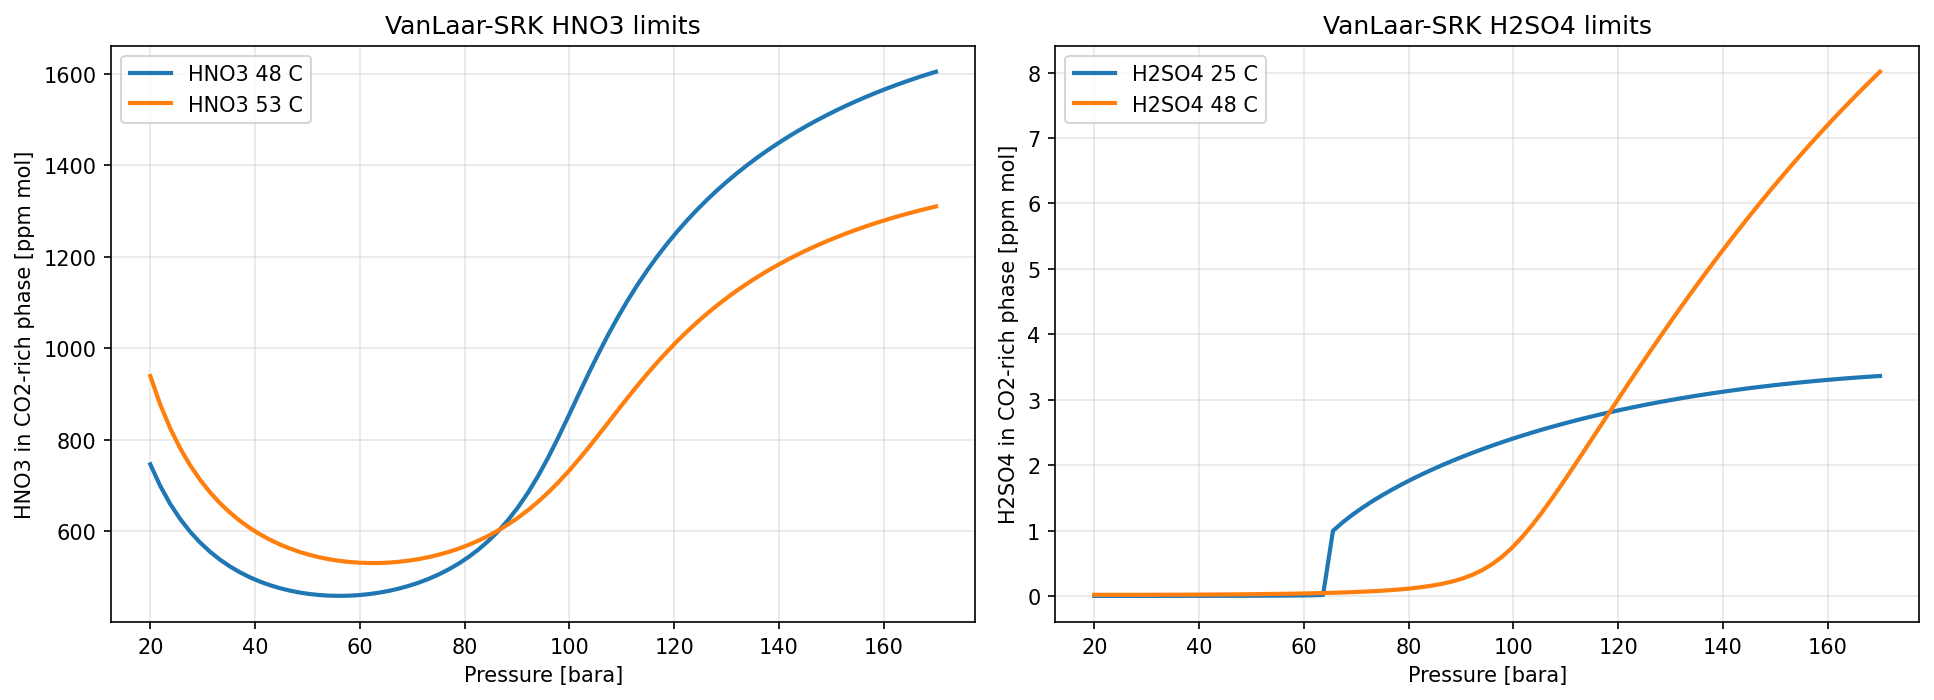

In [5]:
# Visual check: VanLaar acid solubility limits over pressure.
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

pressure_grid = np.linspace(20.0, 170.0, 80)
hno3_48c = [vanlaar_component_solubility_ppm("HNO3", "HNO3", 48.0, p) for p in pressure_grid]
hno3_53c = [vanlaar_component_solubility_ppm("HNO3", "HNO3", 53.0, p) for p in pressure_grid]
h2so4_25c = [vanlaar_component_solubility_ppm("H2SO4", "H2SO4", 25.0, p) for p in pressure_grid]
h2so4_48c = [vanlaar_component_solubility_ppm("H2SO4", "H2SO4", 48.0, p) for p in pressure_grid]

fig, (ax_hno3, ax_h2so4) = plt.subplots(1, 2, figsize=(13, 4.8))
ax_hno3.plot(pressure_grid, hno3_48c, label="HNO3 48 C", lw=2)
ax_hno3.plot(pressure_grid, hno3_53c, label="HNO3 53 C", lw=2)
ax_hno3.set_xlabel("Pressure [bara]")
ax_hno3.set_ylabel("HNO3 in CO2-rich phase [ppm mol]")
ax_hno3.set_title("VanLaar-SRK HNO3 limits")
ax_hno3.grid(True, alpha=0.3)
ax_hno3.legend()

ax_h2so4.plot(pressure_grid, h2so4_25c, label="H2SO4 25 C", lw=2)
ax_h2so4.plot(pressure_grid, h2so4_48c, label="H2SO4 48 C", lw=2)
ax_h2so4.set_xlabel("Pressure [bara]")
ax_h2so4.set_ylabel("H2SO4 in CO2-rich phase [ppm mol]")
ax_h2so4.set_title("VanLaar-SRK H2SO4 limits")
ax_h2so4.grid(True, alpha=0.3)
ax_h2so4.legend()

fig.tight_layout()
LIMITS_PNG = PROJECT_ROOT / "examples" / "notebooks" / "acidwatch_vanlaar_solubility_limits.png"
fig.savefig(LIMITS_PNG, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Saved {LIMITS_PNG.relative_to(PROJECT_ROOT)}")
display(Image(filename=str(LIMITS_PNG)))

In [6]:
# Copy-paste sketch for an AcidWatch adapter implementation.
replacement_sketch = r'''
class SolubilityCCSVanLaarAdapter(BaseAdapter):
    model_id = "solubilityccs_vanlaar"
    display_name = "Solubility CCS - VanLaar SRK"
    valid_substances = ["H2O", "H2SO4", "HNO3"]
    parameters: SolubilityCCSParameters
    category = "PhaseEquilibrium"

    SOURCE_COMPOSITIONS = {
        "HNO3": ("nitric acid", 65.0, 35.0),
        "H2SO4": ("sulfuric acid", 98.0, 2.0),
    }
    COMPONENT_NAMES = {
        "H2O": "water",
        "HNO3": "nitric acid",
        "H2SO4": "sulfuric acid",
    }

    async def run(self) -> RunResult:
        h2o = self.concentrations.get("H2O", 0.0)
        h2so4 = self.concentrations.get("H2SO4", 0.0)
        hno3 = self.concentrations.get("HNO3", 0.0)
        temp_c = self.conditions.temperature
        pres = self.conditions.pressure

        acid_symbols = [symbol for symbol, value in [("H2SO4", h2so4), ("HNO3", hno3)] if value > 0.0]
        if not acid_symbols:
            # Gap: route pure CO2-H2O binary to the existing model or add a water-only helper.
            return [], TextResult(data="VanLaar acid helper requires HNO3 or H2SO4 source.", label="Solubility Output")

        co2_rich_concs = {}
        table_rows = []
        for acid_symbol in acid_symbols:
            acid_name, acid_wt, water_wt = self.SOURCE_COMPOSITIONS[acid_symbol]
            acid_limit = SystemVanLaarActivitySRK.componentSolubilityInCarbonDioxidePpm(
                self.COMPONENT_NAMES[acid_symbol], acid_name, acid_wt, water_wt, temp_c, pres
            )
            acid_feed = self.concentrations.get(acid_symbol, 0.0)
            co2_rich_concs[acid_symbol] = min(acid_feed, acid_limit)
            table_rows.append((acid_symbol, acid_feed, acid_limit))

            if h2o > 0.0:
                water_limit = SystemVanLaarActivitySRK.componentSolubilityInCarbonDioxidePpm(
                    "water", acid_name, acid_wt, water_wt, temp_c, pres
                )
                co2_rich_concs["H2O"] = min(h2o, water_limit)

        phases = [Phase(kind="co2-rich", fraction=1.0, concentrations=co2_rich_concs)]
        # Gap: if feed exceeds solubility, a full mass-balance flash is needed to calculate aqueous fraction.
        table = "VanLaar-SRK CO2-rich solubility screening; see notebook readiness matrix."
        return phases, TextResult(data=table, label="Solubility Output")
'''

display(Markdown("### Adapter replacement sketch\n```python\n" + replacement_sketch.strip() + "\n```"))

### Adapter replacement sketch
```python
class SolubilityCCSVanLaarAdapter(BaseAdapter):
    model_id = "solubilityccs_vanlaar"
    display_name = "Solubility CCS - VanLaar SRK"
    valid_substances = ["H2O", "H2SO4", "HNO3"]
    parameters: SolubilityCCSParameters
    category = "PhaseEquilibrium"

    SOURCE_COMPOSITIONS = {
        "HNO3": ("nitric acid", 65.0, 35.0),
        "H2SO4": ("sulfuric acid", 98.0, 2.0),
    }
    COMPONENT_NAMES = {
        "H2O": "water",
        "HNO3": "nitric acid",
        "H2SO4": "sulfuric acid",
    }

    async def run(self) -> RunResult:
        h2o = self.concentrations.get("H2O", 0.0)
        h2so4 = self.concentrations.get("H2SO4", 0.0)
        hno3 = self.concentrations.get("HNO3", 0.0)
        temp_c = self.conditions.temperature
        pres = self.conditions.pressure

        acid_symbols = [symbol for symbol, value in [("H2SO4", h2so4), ("HNO3", hno3)] if value > 0.0]
        if not acid_symbols:
            # Gap: route pure CO2-H2O binary to the existing model or add a water-only helper.
            return [], TextResult(data="VanLaar acid helper requires HNO3 or H2SO4 source.", label="Solubility Output")

        co2_rich_concs = {}
        table_rows = []
        for acid_symbol in acid_symbols:
            acid_name, acid_wt, water_wt = self.SOURCE_COMPOSITIONS[acid_symbol]
            acid_limit = SystemVanLaarActivitySRK.componentSolubilityInCarbonDioxidePpm(
                self.COMPONENT_NAMES[acid_symbol], acid_name, acid_wt, water_wt, temp_c, pres
            )
            acid_feed = self.concentrations.get(acid_symbol, 0.0)
            co2_rich_concs[acid_symbol] = min(acid_feed, acid_limit)
            table_rows.append((acid_symbol, acid_feed, acid_limit))

            if h2o > 0.0:
                water_limit = SystemVanLaarActivitySRK.componentSolubilityInCarbonDioxidePpm(
                    "water", acid_name, acid_wt, water_wt, temp_c, pres
                )
                co2_rich_concs["H2O"] = min(h2o, water_limit)

        phases = [Phase(kind="co2-rich", fraction=1.0, concentrations=co2_rich_concs)]
        # Gap: if feed exceeds solubility, a full mass-balance flash is needed to calculate aqueous fraction.
        table = "VanLaar-SRK CO2-rich solubility screening; see notebook readiness matrix."
        return phases, TextResult(data=table, label="Solubility Output")
```

## Conclusion

The VanLaar-SRK model is ready for an AcidWatch screening adapter for acid-source CO2-rich ppm limits: HNO3, H2SO4, and acid-source water can be calculated directly with the existing NeqSim API.

It is not yet a strict drop-in replacement for the current `solubilityccs.Fluid.flash_activity()` path because the current AcidWatch adapter extracts `fluid.betta`, phase fractions, and aqueous-phase compositions. Those require either a full VanLaar mass-balance flash interface or an AcidWatch convention that treats the VanLaar helper as a solubility-limit screening model.